In [2]:
# Run this cell to install required libraries (only once)
!pip install librosa opencv-python matplotlib scikit-learn tensorflow tqdm


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, GlobalAveragePooling2D, Input, TimeDistributed, Reshape, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print(" Step 1 Complete: Libraries imported successfully.")


 Step 1 Complete: Libraries imported successfully.


In [20]:
import os

print(" Dataset path exists:", os.path.exists("dataset"))
print(" Contents of 'dataset':", os.listdir("dataset"))


 Dataset path exists: True
 Contents of 'dataset': ['test', 'train', '.ipynb_checkpoints']


In [22]:
for folder in ['train', 'test']:
    for label in ['child', 'women', 'normal']:
        path = os.path.join("dataset", folder, label)
        print(f"{path} exists? -> {os.path.exists(path)} | Contains: {len(os.listdir(path)) if os.path.exists(path) else 'N/A'} files")


dataset/train/child exists? -> True | Contains: 2106 files
dataset/train/women exists? -> True | Contains: 2005 files
dataset/train/normal exists? -> True | Contains: 2074 files
dataset/test/child exists? -> True | Contains: 1648 files
dataset/test/women exists? -> True | Contains: 1668 files
dataset/test/normal exists? -> True | Contains: 1620 files


In [2]:
import os
import librosa
import numpy as np
import cv2


In [4]:
def audio_to_mel_rgb(filepath, n_mels=128, duration=3, sr=32000):
    y, _ = librosa.load(filepath, sr=sr, duration=duration)

    # Simple noise gating
    y = np.where(np.abs(y) < 0.02, 0, y)

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    db = librosa.power_to_db(mel, ref=np.max)

    # Resize and normalize to image
    db_resized = cv2.resize(db, (224, 224))
    norm = cv2.normalize(db_resized, None, 0, 255, cv2.NORM_MINMAX)
    rgb = np.stack([norm]*3, axis=-1).astype(np.uint8)
    return rgb


In [6]:
test_file = "dataset/train/child"
first_wav = [f for f in os.listdir(test_file) if f.endswith(".wav")][0]
img = audio_to_mel_rgb(os.path.join(test_file, first_wav))

print(" Success! Image shape:", img.shape)


 Success! Image shape: (224, 224, 3)


In [8]:
DATASET_PATH = "dataset"

labels_map = {
    "child": 0,
    "women": 1,
    "normal": 2
}


In [10]:
from tqdm import tqdm

X = []
y = []

for folder in ['train', 'test']:
    for label_name in labels_map:
        class_path = os.path.join(DATASET_PATH, folder, label_name)
        label = labels_map[label_name]

        # Confirm folder exists
        if not os.path.exists(class_path):
            print(f" Missing folder: {class_path}")
            continue

        # Loop through files
        for file in tqdm(os.listdir(class_path), desc=f"{folder}/{label_name}"):
            if file.lower().endswith(".wav"):
                file_path = os.path.join(class_path, file)
                try:
                    img = audio_to_mel_rgb(file_path)
                    if img.shape == (224, 224, 3):
                        X.append(img)
                        y.append(label)
                except Exception as e:
                    print(f" Error processing {file}: {e}")


test/normal: 100%|█████████████████████████| 1620/1620 [00:09<00:00, 174.91it/s]


In [12]:
X = np.array(X)
y = np.array(y)

print(" Feature Extraction Completed")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique Classes: {np.unique(y)}")


 Feature Extraction Completed
X shape: (11121, 224, 224, 3)
y shape: (11121,)
Unique Classes: [0 1 2]


In [14]:
X = X.astype("float32") / 255.0


In [15]:
from tensorflow.keras.utils import to_categorical

y_encoded = to_categorical(y, num_classes=3)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y, random_state=42
)

print(" Train/Test Split Complete")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


✅ Train/Test Split Complete
X_train shape: (8896, 224, 224, 3)
X_test shape: (2225, 224, 224, 3)


In [20]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Reshape, TimeDistributed, LSTM, Bidirectional, Dense, GlobalAveragePooling2D, Dropout

# Input shape
input_shape = (224, 224, 3)
inputs = Input(shape=input_shape)

# MobileNetV2 base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False

x = base_model(inputs)
x = GlobalAveragePooling2D()(x)

# Add a dimension to simulate sequence (1 timestep)
x = Reshape((1, -1))(x)

# BiLSTM Layer
x = Bidirectional(LSTM(128, return_sequences=False))(x)

# Final classification layers
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,701,571 (14.12 MB)

 Trainable params: 1,443,587 (5.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 111s 389ms/step - accuracy: 0.7501 - loss: 0.6432 - val_accuracy: 0.9272 - val_loss: 0.2318
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 97s 350ms/step - accuracy: 0.9247 - loss: 0.2385 - val_accuracy: 0.9452 - val_loss: 0.1688
Epoch 3/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 99s 357ms/step - accuracy: 0.9473 - loss: 0.1635 - val_accuracy: 0.9533 - val_loss: 0.1378
Epoch 4/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 101s 362ms/step - accuracy: 0.9562 - loss: 0.1359 - val_accuracy: 0.9600 - val_loss: 0.1230
Epoch 5/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 106s 381ms/step - accuracy: 0.9662 - loss: 0.1130 - val_accuracy: 0.9645 - val_loss: 0.1036
Epoch 6/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 112s 403ms/step - accuracy: 0.9647 - loss: 0.1073 - val_accuracy: 0.9596 - val_loss: 0.1137
Epoch 7/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 106s 380ms/step - accuracy: 0.9723 - loss: 0.0893 - val_accuracy: 0.9667 - val_loss: 0.0911
Epoch 8/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 109s 391ms/step - accuracy: 0.9769 - l

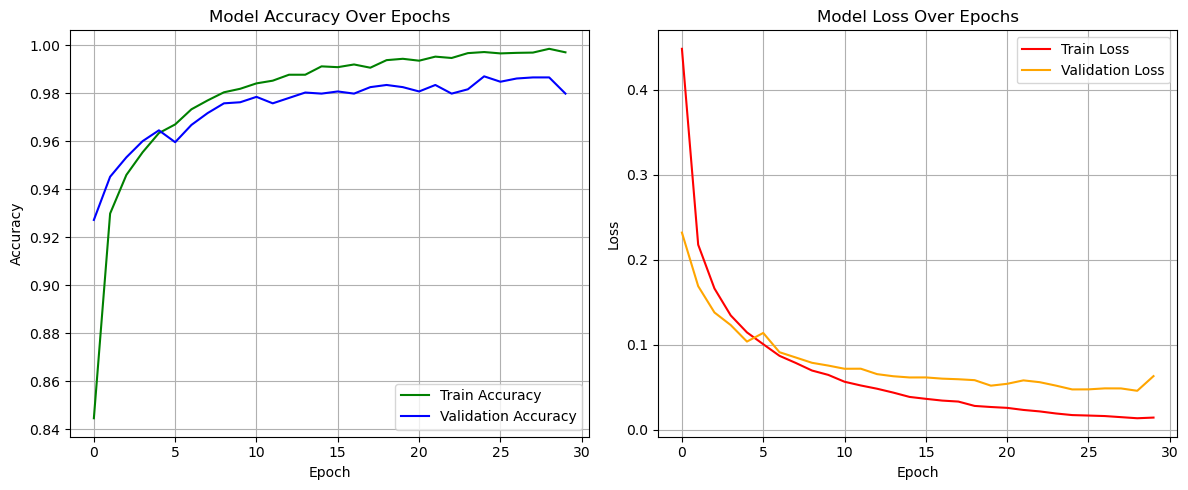

In [26]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
from sklearn.metrics import classification_report
import numpy as np

# Predict
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)


70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 264ms/step


In [30]:
labels = ['Child Scream', 'Women Scream', 'Normal']

report = classification_report(y_true_classes, y_pred_classes, target_names=labels)
print("🔍 Classification Report:\n")
print(report)


🔍 Classification Report:

              precision    recall  f1-score   support

Child Scream       0.96      0.99      0.97       751
Women Scream       0.99      0.95      0.97       735
      Normal       0.99      1.00      1.00       739

    accuracy                           0.98      2225
   macro avg       0.98      0.98      0.98      2225
weighted avg       0.98      0.98      0.98      2225



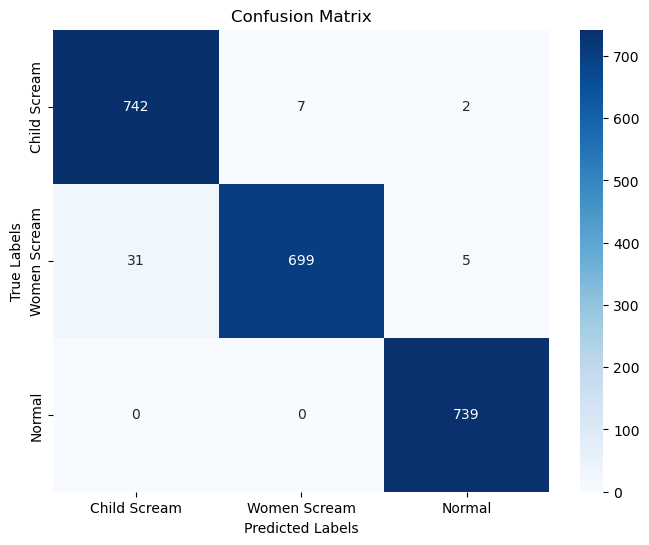

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Define class labels
labels = ['Child Scream', 'Women Scream', 'Normal']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [34]:
from sklearn.metrics import accuracy_score

overall_acc = accuracy_score(y_true_classes, y_pred_classes)
print(f" Overall Accuracy: {overall_acc * 100:.2f}%")


✅ Overall Accuracy: 97.98%


In [36]:
# Assuming 'cm' is already defined as confusion matrix
# If not, run this again:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Class labels (order should match model output)
labels = ['Child Scream', 'Women Scream', 'Normal']

# Calculate and print per-class accuracy
print(" Per-Class Accuracy:")
for i, label in enumerate(labels):
    correct = cm[i][i]
    total = cm[i].sum()
    acc = correct / total * 100
    print(f"{label}: {acc:.2f}%")


 Per-Class Accuracy:
Child Scream: 98.80%
Women Scream: 95.10%
Normal: 100.00%
